<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab H: Confidence Interval

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

-1.9859550571579969

76.777777777777771

73.222222222222229

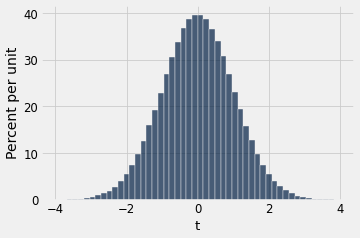

In [6]:
sample_size=81

dist = Table().with_column('t', standard_t(sample_size-1, 1000000))
dist.hist(bins=50, range=make_array(-4,4))

cv = percentile(2.5, dist.column('t'))
cv

75 + 2*8/sqrt(81)
75 - 2*8/sqrt(81)

## Insurance Claims

### Business Decision

An insurance company has a special team of 10 analysts to process complex claims.   The Director of Complex Claims Processing has just learned that the volume of complex claims coming to his team might increase from the current 1500 claims per month to 1700 claims per month, or even as high as 2000 claims per month.  The General Manager asks the Director what impact he expects this will have on the operation.

Should the director accept 1700 claims per month?  Should the director accept 2000 claims per month?

### Data

Here is the record of average labor (in minutes) to process a claim, one average for each of 50 days.  
70, 72, 70, 73, 73, 30, 70, 81, 60, 60, 70, 62, 20, 50, 70, 45, 60, 75, 10, 84,  
21, 60, 66, 81, 32, 24, 60, 67, 67, 56, 45, 49, 80, 45, 39, 67, 80, 87, 50, 51,  
21, 60, 66, 81, 42, 24, 60, 67, 99, 81

Show the sample size, sample mean, sample standard deviation, and
a histogram of the sampled averages (10 bins) with range 52.9166 to 64.4033 highlighted.

50

58.659999999999997

20.230921978042243

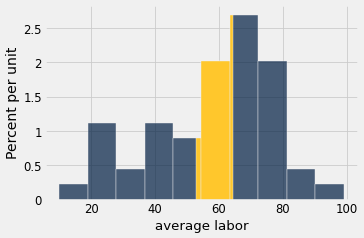

In [2]:
sample = Table().with_column('average labor', make_array(70, 72, 70, 73, 73, 30, 70, 81, 60, 60,
                                                         70, 62, 20, 50, 70, 45, 60, 75, 10, 84,
                                                         21, 60, 66, 81, 32, 24, 60, 67, 67, 56,
                                                         45, 49, 80, 45, 39, 67, 80, 87, 50, 51,
                                                         21, 60, 66, 81, 42, 24, 60, 67, 99, 81))

sample_size = sample.num_rows
sample_mean = mean(sample.column('average labor'))
sample_std  = std(sample.column('average labor'), ddof=1)

sample_size
sample_mean
sample_std
sample.hist(bins=10, left_end=52.9166, right_end=64.4033)

### Analysis: Hypothesis Tests

Get 1,000,000 values from the standard t distribution for sample size 50.
Show a histogram of all the values (50 bins, range -4 to 4).

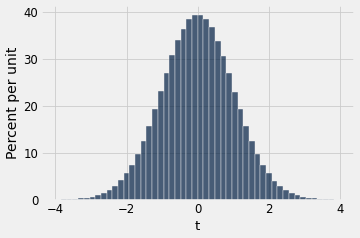

In [3]:
seed(0)
dist = Table().with_column('t', standard_t(sample_size-1, 1000000))
dist.hist(bins=50, range=make_array(-4,4))

Hypothesize that the population mean is 52.9166 or lower.

Calculate and show the sample t, assuming the hypothesized population mean.

Calculate and show the p-value for the sample, assuming this sample t.
This is the probability of a getting the sample (or one with an equal or higher t value)
if the actual population mean is below or equal to 52.9166. 

In [4]:
pop_mean_hypo_1 = 52.9166
pop_mean_hypo_1

sample_t_1 = (sample_mean - pop_mean_hypo_1) / (sample_std / sqrt(sample_size))
sample_t_1

p_value_1 = dist.where('t', are.above_or_equal_to(sample_t_1)).num_rows / dist.num_rows
p_value_1

52.9166

2.0074206659857907

0.024918

Hypothesize that the population mean is 64.4033 or higher.

Calculate and show the sample t, assuming the hypothesized population mean.

Calculate and show the p-value for the sample, assuming this sample t.
This is the probability of a getting the sample (or one with an equal or lower t value)
if the actual population mean is above or equal to 64.4033.

In [5]:
pop_mean_hypo_2 = 64.4033
pop_mean_hypo_2

sample_t_2 = (sample_mean - pop_mean_hypo_2) / (sample_std / sqrt(sample_size))
sample_t_2

p_value_2 = dist.where('t', are.below_or_equal_to(sample_t_2)).num_rows / dist.num_rows
p_value_2

64.4033

-2.0073857142034708

0.025003

Calculate and show the probability of getting the sample (or one even less likely),
assuming that the population mean is below 52.9166 or above 64.4033.

In [6]:
p_value_1 + p_value_2

0.049921

### Analysis: Confidence Interval

Get 1,000,000 values from the standard t distribution for sample size 50.
Show a histogram of all the values (50 bins, range -4 to 4).

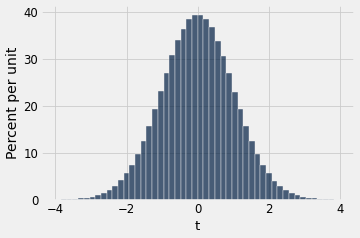

In [7]:
seed(0)
dist = Table().with_column('t', standard_t(sample_size-1, 1000000))
dist.hist(bins=50, range=make_array(-4,4))

Set the confidence level to 95%.  This indicates that you focus on the middle 95% of the standard t distribution.

Calculate and show the probability of t values **below** the middle 95% of the standard t distribution.  
Calculate and show the probability of t values **above** the middle 95% of the standard t distribution. 

In [8]:
confidence_level = 0.95
confidence_level

prob_lower = (1 - confidence_level)/2
prob_upper = (1 - confidence_level)/2
prob_lower
prob_upper

0.95

0.025000000000000022

0.025000000000000022

Calculate and show the critical values corresponding to the probabilities.

Show a histogram of all the t values (50 bins, range -4 to 4) with values below the middle 95% highlighted.  
Show a histogram of all the t values (50 bins, range -4 to 4) with values above the middle 95% highlighted.

-2.007408497250676

2.007408497250676

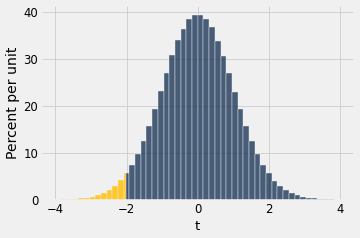

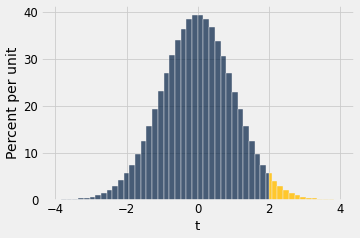

In [9]:
cv_lower = percentile(prob_lower*100, dist.column('t'))
cv_upper = -cv_lower
cv_lower
cv_upper

dist.hist(bins=50, range=make_array(-4,4), left_end=-4, right_end=cv_lower)
dist.hist(bins=50, range=make_array(-4,4), left_end=cv_upper, right_end=4)

Calculate and show hypothetical population means corresponding to the lower and upper critical values, like this:

$$
\textit{critical value} = \cfrac{\textit{sample mean} - \textit{pop mean hypo}}{\left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}}\right)}
$$

<br>

$$
\textit{critical value} \times \left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}} \right) = \textit{sample mean} - \textit{pop mean hypo}  
$$

<br>

$$
\textit{critical value} \times \left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}} \right) - \textit{sample mean} = - \textit{pop mean hypo}
$$

<br>

$$
- \textit{critical value} \times \left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}} \right) + \textit{sample mean} = \textit{pop mean hypo}
$$

<br>

$$
\textit{pop mean hypo} =  \textit{sample mean} - \textit{critical value} \times \left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}} \right)
$$

In [10]:
mean_high = sample_mean - ( cv_lower * sample_std / sqrt(sample_size) )
mean_high

mean_low = sample_mean - ( cv_upper * sample_std / sqrt(sample_size) )
mean_low

64.403365184221499

52.916634815778501

Again, calculate and show a hypothetical population mean corresponding to the lower critical value, like this:

$$
\textit{pop mean hypo} =  \textit{sample mean} - \textit{lower critical value} \times \left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}} \right)
$$

Note that $\textit{upper critical value} = - \textit{lower critical value}$.  So now, calculate and show a hypothetical population mean corresponding to the upper critical value, like this:

$$
\textit{pop mean hypo} =  \textit{sample mean} + \textit{lower critical value} \times \left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}} \right)
$$

In [11]:
mean_high = sample_mean - ( cv_lower * sample_std / sqrt(sample_size) )
mean_high

mean_low = sample_mean + ( cv_lower * sample_std / sqrt(sample_size) )
mean_low

64.403365184221499

52.916634815778501

Hence, the formula for confidence interval:

$$
\textit{pop mean hypo} =  \textit{sample mean} \pm \textit{critical value} \times \left(\cfrac{\textit{sample standard deviation}}{\sqrt{\textit{sample size}}} \right)
$$

### Analysis: Business Impact

Recall that the team comprises 10 analysts.

Calculate and show the labor (expressed in minutes) available in a 21-day month,
assuming all the analysts work 8 hours per day.

In [12]:
number_of_analysts = 10
number_of_analysts

labor_available = number_of_analysts * 8 * 60 * 21
labor_available

10

100800

Calculate and show how many claims you would expect to process completely in a month,
if the actual average labor per claim is the sample average labor per claim.

Calculate and show how many claims would be left unprocessed, assuming the team receives 2000 claims per month.  
Calculate and show how many claims would be left unprocessed, assuming the team receives 1700 claims per month.  
Calculate and show how many claims would be left unprocessed, assuming the team receives 1500 claims per month.

In [13]:
claims_processed = int(labor_available/sample_mean)
claims_processed

max(0, 2000 - claims_processed)
max(0, 1700 - claims_processed)
max(0, 1500 - claims_processed)

1718

282

0

0

Calculate and show how many claims you would expect to process completely in a month,
if the actual average labor per claim is the lower end of the 95% confidence interval.

Calculate and show how many claims would be left unprocessed, assuming the team receives 2000 claims per month.  
Calculate and show how many claims would be left unprocessed, assuming the team receives 1700 claims per month.  
Calculate and show how many claims would be left unprocessed, assuming the team receives 1500 claims per month.

In [14]:
claims_processed = int(labor_available/mean_low)
claims_processed

max(0, 2000 - claims_processed)
max(0, 1700 - claims_processed)
max(0, 1500 - claims_processed)

1904

96

0

0

Calculate and show how many claims you would expect to process completely in a month,
if the actual average labor per claim is the upper end of the 95% confidence interval.

Calculate and show how many claims would be left unprocessed, assuming the team receives 2000 claims per month.  
Calculate and show how many claims would be left unprocessed, assuming the team receives 1700 claims per month.  
Calculate and show how many claims would be left unprocessed, assuming the team receives 1500 claims per month.

In [15]:
claims_processed = int(labor_available/mean_high)
claims_processed

max(0, 2000 - claims_processed)
max(0, 1700 - claims_processed)
max(0, 1500 - claims_processed)

1565

435

135

0

## Hypothesis Tests vs. Confidence Interval: The Math

For your reference, here is the math showing the relationship between hypothesis tests and a confidence interval.

DEFINITIONS

* $t$ is the sample t
* $\bar{x}$ is the sample mean
* $\hat{\mu}$ is a hypothetical population mean
* $s$ is the sample standard deviation
* $n$ is the sample size
<br><br>
* $cv_{\scriptsize{0.025 , n-1}}$ is the critical value at the lower 2.5% of t values in a standard t distribution taken at sample size n
* $cv_{\scriptsize{0.975 , n-1}}$ is the critical value at the lower 97.5% (upper 2.5%) of t values in a standard t distribution taken at sample size n
* $percentile_{\scriptsize{0.025}}(...)$ is the 2.5th percentile of a distribution
* $percentile_{\scriptsize{0.975}}(...)$ is the 97.5th percentile of a distribution
* $\vec{T}_{n-1}$ is a standard t distribution taken at sample size n
<br><br>

VIEWED AS HYPOTHESIS TESTS<br>
Set $\hat{\mu}$, calculate $t$, compare $t$ to $cv$

* $t = \large{\frac{\bar{x} - \hat{\mu}}{\frac{s}{\sqrt{n}}}}$
* $cv_{\scriptsize{0.025 , n-1}} = percentile_{\scriptsize{0.025}}(\vec{T}_{n-1})$
* $cv_{\scriptsize{0.975 , n-1}} = percentile_{\scriptsize{0.975}}(\vec{T}_{n-1}) = - cv_{\scriptsize{0.025 , n-1}}$
<br><br>

VIEWED AS A CONFIDENCE INTERVAL<br>
Set $t$, calculate $\hat{\mu}$ based on $cv$

* If $t = cv_{\scriptsize{0.025 , n-1}}$, then $\hat{\mu} = \bar{x} - cv_{\scriptsize{0.025 , n-1}} \frac{s}{\sqrt{n}}$
* If $t = cv_{\scriptsize{0.975 , n-1}}$, then $\hat{\mu} = \bar{x} + cv_{\scriptsize{0.025 , n-1}} \frac{s}{\sqrt{n}}$

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised February 26, 2024
</span>
</p>